In [2]:
using JLD2
using PyPlot
using Statistics
using HDF5
using Interpolations

### Load data from Julian simulations

In [4]:
pathname_sim_julian = "Groundstate_Bext_90_deg_as_98.h5"
file = h5open(pathname_sim_julian, "r")
n = read(file["n"])
nxy = read(file["nxy"])
nxz = read(file["nxz"])
x = read(file["x"])
y = read(file["y"])
z = read(file["z"])
dx, dy, dz = read(file["dx"])[1], read(file["dy"])[1], read(file["dz"])[1];

## In the vertical plane, slice @ y = 0

In [10]:
close("all")
fig = subplot()

n_cut_y_0 = n[:, Int(length(y)/2), :]

imshow(n_cut_y_0', extent=[x[1], x[end], z[1], z[end]])

# Cut the central droplet
axhline(3, color="white", linewidth=0.5), axhline(-3, color="white", linewidth=0.5)
axvline(15, color="white", linewidth=0.5), axvline(-15, color="white", linewidth=0.5)

xlabel(L"X (in $\mu m$)")
ylabel(L"Z (in $\mu m$)")

suptitle(L"n (in $\mu m^{-1}$)")

pygui(true); show();
# pygui(false);

<sys>:0: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


In [11]:
close("all")
fig = subplot()

imshow(n_cut_y_0' .* dx*dy*dz, extent=[x[1], x[end], z[1], z[end]])

# Cut the central droplet
axhline(3, color="white", linewidth=0.5), axhline(-3, color="white", linewidth=0.5)
axvline(15, color="white", linewidth=0.5), axvline(-15, color="white", linewidth=0.5)

xlabel(L"X (in $\mu m$)")
ylabel(L"Z (in $\mu m$)")

suptitle(L"N")

pygui(true); show();
# pygui(false);

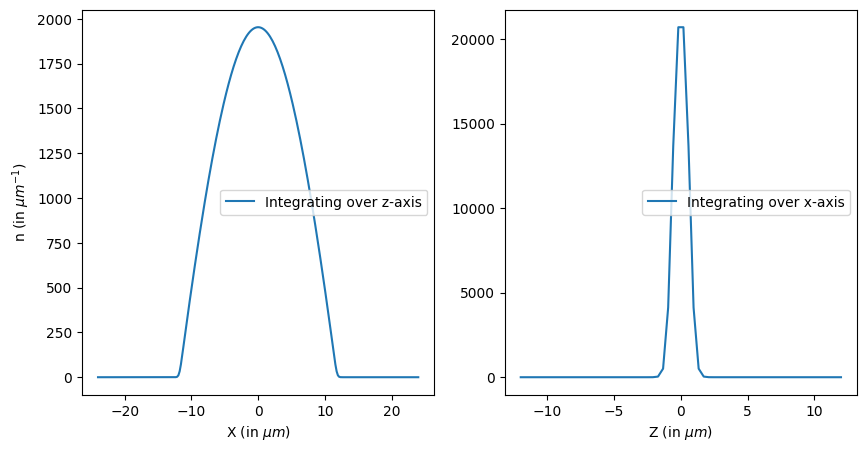

In [12]:
close("all")
fig, axes = subplots(1, 2, figsize=(10, 5))

axes[1].plot(x', sum(n_cut_y_0, dims=2).*dz, label="Integrating over z-axis")
axes[2].plot(z', sum(n_cut_y_0, dims=1)'.*dx, label="Integrating over x-axis")
axes[1].legend(), axes[2].legend()

axes[1].set_xlabel(L"X (in $\mu m$)")
axes[2].set_xlabel(L"Z (in $\mu m$)")

axes[1].set_ylabel(L"n (in $\mu m^{-1}$)")

# pygui(true); show();
pygui(false);

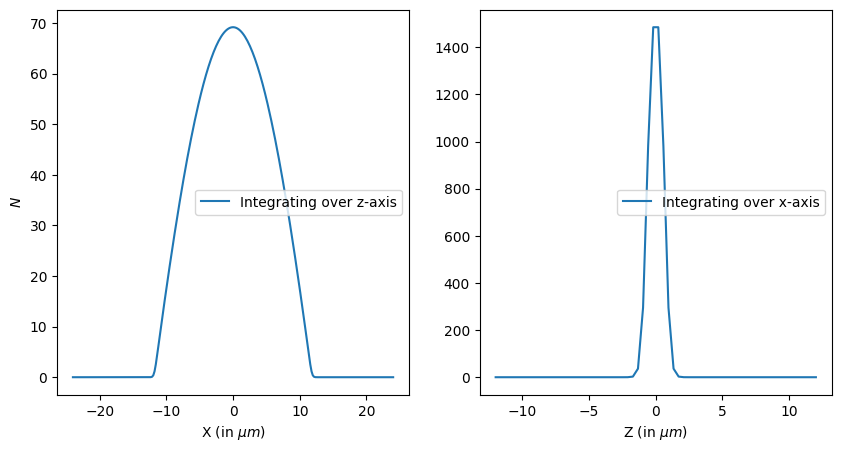

In [13]:
close("all")
fig, axes = subplots(1, 2, figsize=(10, 5))

axes[1].plot(x', sum(n_cut_y_0, dims=2).*dx*dy*dz, label="Integrating over z-axis")
axes[2].plot(z', sum(n_cut_y_0, dims=1)'.*dx*dy*dz, label="Integrating over x-axis")
axes[1].legend(), axes[2].legend()

axes[1].set_xlabel(L"X (in $\mu m$)")
axes[2].set_xlabel(L"Z (in $\mu m$)")

axes[1].set_ylabel(L"N")

# pygui(true); show();
pygui(false);

## In the horizontal plane, integrating along the z-axis

### Cut the central stripe

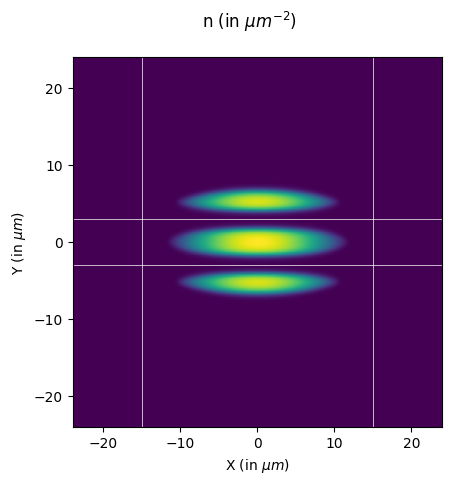

In [14]:
close("all")
fig = subplot()

imshow(nxy', extent=[x[1], x[end], y[1], y[end]])

# Cut the central droplet
axhline(3, color="white", linewidth=0.5), axhline(-3, color="white", linewidth=0.5)
axvline(15, color="white", linewidth=0.5), axvline(-15, color="white", linewidth=0.5)

xlabel(L"X (in $\mu m$)")
ylabel(L"Y (in $\mu m$)")

suptitle(L"n (in $\mu m^{-2}$)")

# pygui(true); show();
pygui(false);

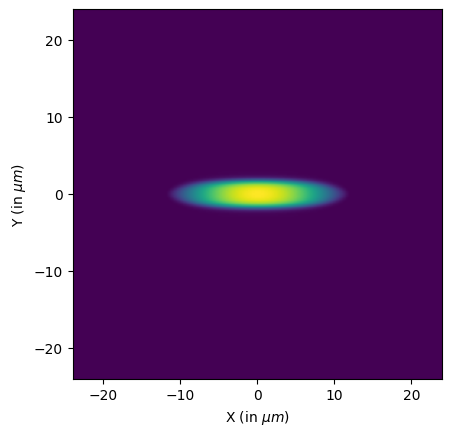

In [15]:
close("all")
fig = subplot()

CS_nxy = nxy .* (((x.>-15) .* (x.<15))' * ((y.>-3) .* (y.<3))) # Central stripe
imshow(CS_nxy', extent=[x[1], x[end], y[1], y[end]])

xlabel(L"X (in $\mu m$)")
ylabel(L"Y (in $\mu m$)")

# pygui(true); show();
pygui(false);

In [16]:
println("Total nbr of atoms = $(sum(nxy)*dx*dy)")
println("Nbr of atoms in central stripe = $(sum(CS_nxy)*dx*dy)")

Total nbr of atoms = 200000.0
Nbr of atoms in central stripe = 88675.12621931208


### Plot the density integrated over x/y

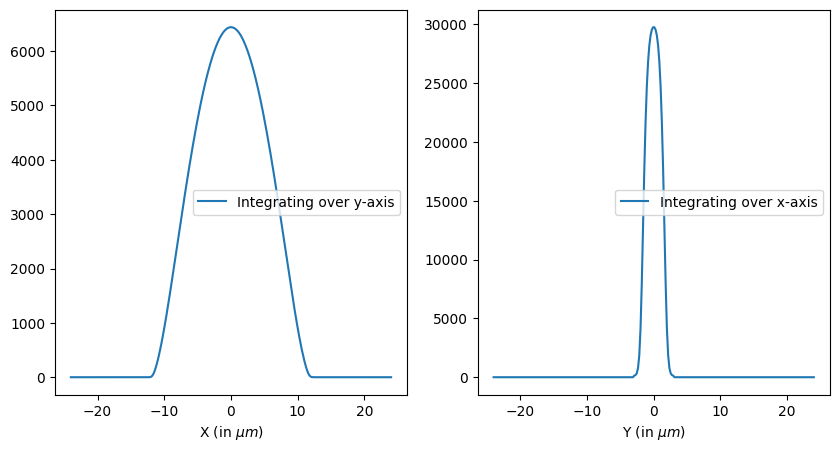

In [17]:
close("all")
fig, axes = subplots(1, 2, figsize=(10, 5))

axes[1].plot(x', sum(CS_nxy, dims=2).*dy, label="Integrating over y-axis")
axes[2].plot(y', sum(CS_nxy, dims=1)'.*dx, label="Integrating over x-axis")
axes[1].legend(), axes[2].legend()

axes[1].set_xlabel(L"X (in $\mu m$)")
axes[2].set_xlabel(L"Y (in $\mu m$)")

# pygui(true); show();
pygui(false);

## Plot the density distribution of the CS

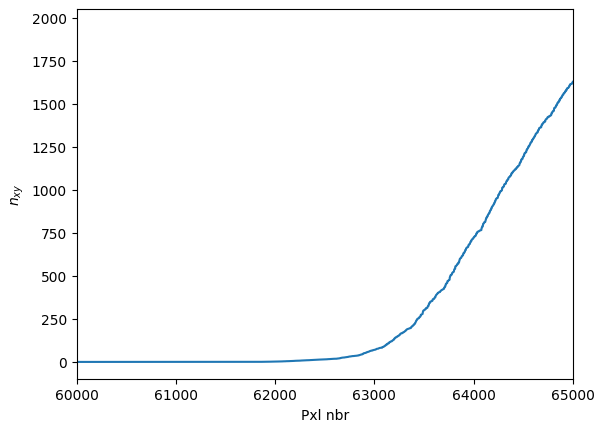

In [18]:
close("all")
fig = subplot()

sorted_density_distrib = sort([CS_nxy[i, j] for i = 1:size(CS_nxy)[1] for j = 1:size(CS_nxy)[2]])
plot(sorted_density_distrib)

xlabel("Pxl nbr")
ylabel(L"n_{xy}")

xlim(60000, 65000)

# pygui(true); show();
pygui(false);

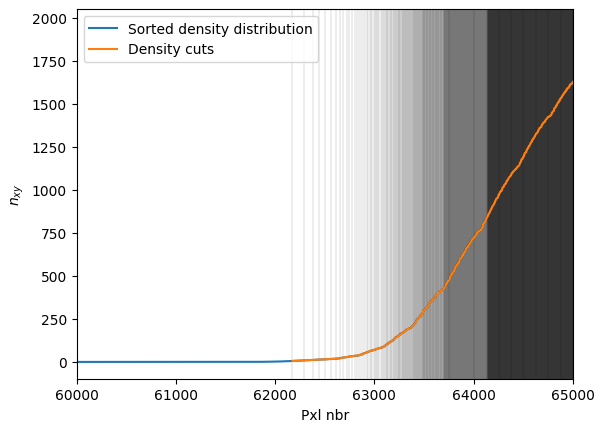

In [19]:
CS_densities_cuts = []
pxl_nbr_CS_densities_cuts = []

sorted_density_distrib = sort([CS_nxy[i, j] for i = 1:size(CS_nxy)[1] for j = 1:size(CS_nxy)[2]])


close("all")
fig = subplot()

plot(sorted_density_distrib, label="Sorted density distribution")

atom_counter = 0
for i = 1:length(CS_nxy)
    atom_counter += sorted_density_distrib[i] *dx*dy
    if atom_counter > 30
        # println(atom_counter)
        axvline(i, linewidth=0.1, color="black")
        atom_counter = 0
        push!(CS_densities_cuts, sorted_density_distrib[i])
        push!(pxl_nbr_CS_densities_cuts, i)
    end
end

plot(pxl_nbr_CS_densities_cuts, CS_densities_cuts, label="Density cuts")

xlim(60000, 65000)

xlabel("Pxl nbr")
ylabel(L"n_{xy}")

legend()

# pygui(true); show()
pygui(false);

In [20]:
println("Maximum atom nbr per cut = $(CS_densities_cuts[end]*dx*dy)")

Maximum atom nbr per cut = 69.19003247465906


### Interpolate the density distribution

In [21]:
step_itp = 1e-3
pxl_interpolation = [1:step_itp:length(sorted_density_distrib);]
itp = linear_interpolation([1:length(sorted_density_distrib);], sorted_density_distrib)
interpolated_density_distribution = itp(pxl_interpolation);

In [ ]:
close("all")
fig = subplot()

plot([1:length(sorted_density_distrib);], sorted_density_distrib, label="Sorted density distribution", marker="x")
plot(pxl_interpolation, interpolated_density_distribution, label="Interpolated density distribution", marker="x", markersize=4, linestyle="--")

xlim(pxl_interpolation[end-50], pxl_interpolation[end])
ylim(interpolated_density_distribution[end-50], interpolated_density_distribution[end])

xlabel("Pxl nbr")
ylabel(L"n_{xy}")

legend()

# pygui(true); show()
pygui(false);

In [22]:
CS_densities_cuts_interpolated = []
pxl_nbr_CS_densities_cuts_interpolated = []
atom_nbr=[]


# close("all")
# fig = subplot()

# plot([1:length(sorted_density_distrib);], sorted_density_distrib, label="Sorted density distribution", marker="x", markersize=8)

atom_counter = 0
for i = 1:length(interpolated_density_distribution)
    atom_counter += interpolated_density_distribution[i] * dx*dy*step_itp
    push!(atom_nbr, atom_counter)

    if atom_counter > 30
        # axvline(pxl_interpolation[i], linewidth=0.1, color="black")
        push!(CS_densities_cuts_interpolated, interpolated_density_distribution[i])
        push!(pxl_nbr_CS_densities_cuts_interpolated, pxl_interpolation[i])
        atom_counter = 0
    end
end

# plot(pxl_interpolation, interpolated_density_distribution, label="Interpolated density distribution", marker="x", markersize=4, linestyle="--")
# plot(pxl_nbr_CS_densities_cuts_interpolated, CS_densities_cuts_interpolated, label="Density cuts", linestyle="--", marker="x")

# # xlim(60000, 65000)
# xlim(pxl_interpolation[end-100], pxl_interpolation[end])
# ylim(interpolated_density_distribution[end-100], interpolated_density_distribution[end])

# xlabel("Pxl nbr")
# ylabel(L"n_{xy}")

# legend()

# # pygui(true); show()
# pygui(false);

In [ ]:
close("all")
fig = subplot()
plot(pxl_interpolation[end-1000:end], atom_nbr[end-1000:end], marker="x")

# xlim(pxl_interpolation[end-100], pxl_interpolation[end-100:end])

xlabel("Pxl nbr")
ylabel("Atom nbr")

# pygui(true); show()
pygui(false)

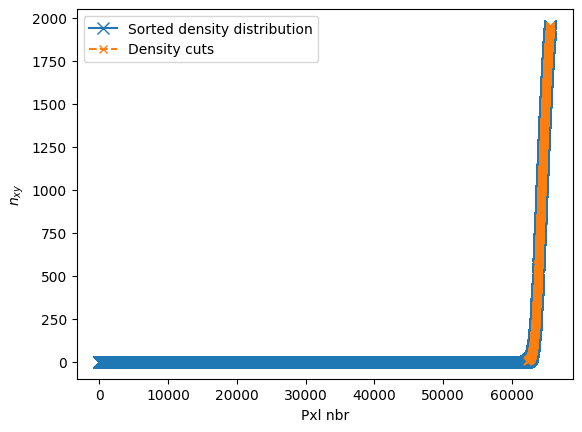

In [21]:
close("all")
fig = subplot()

plot([1:length(sorted_density_distrib);], sorted_density_distrib, label="Sorted density distribution", marker="x", markersize=8)

plot(pxl_nbr_CS_densities_cuts_interpolated, CS_densities_cuts_interpolated, label="Density cuts", linestyle="--", marker="x")

# xlim(60000, 65000)
# xlim(pxl_nbr_CS_densities_cuts_interpolated[end-100], pxl_nbr_CS_densities_cuts_interpolated[end])
# ylim(CS_densities_cuts_interpolated[end-100], CS_densities_cuts_interpolated[end])

xlabel("Pxl nbr")
ylabel(L"n_{xy}")

legend()

# pygui(true); show()
pygui(false);

In [ ]:
println("Nbr of atoms in central stripe = $(sum(CS_nxy)*dx*dy)")
println("Nbr of atoms in central stripe = $(sum(sorted_density_distrib)*dx*dy)")
step_size_CS_densities_cuts_interpolated = pxl_nbr_CS_densities_cuts_interpolated[2:end]-pxl_nbr_CS_densities_cuts_interpolated[1:end-1]
println("Nbr of atoms in central stripe = $(length(CS_densities_cuts_interpolated)*30)")
println("Nbr of atoms in central stripe = $(sum(CS_densities_cuts_interpolated[2:end].*step_size_CS_densities_cuts_interpolated)*dx*dy)")

In [ ]:
λ = 421e-9 # Lambda im m
CS_densities_cuts_interpolated_norm = CS_densities_cuts_interpolated * (λ/1e-6)^2 # Nbr of atoms in a surface of lambda^2

In [6]:
close("all")
fig = subplot()
plot(pxl_nbr_CS_densities_cuts_interpolated, CS_densities_cuts_interpolated_norm, label="Density cuts", linestyle="--", marker="x")
xlabel("Pxl nbr")
ylabel(L"$n_{xy}$ (atoms per $\lambda^{-2}$)")


legend()
pygui(true); show()
# pygui(false);

LoadError: UndefVarError: `pxl_nbr_CS_densities_cuts_interpolated` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
@save "Density_distributions\\$(pathname_sim_julian[1:end-3]).jld2" CS_densities_cuts_interpolated_norm

In [7]:
@load "Density_distributions\\$(pathname_sim_julian[1:end-3]).jld2" CS_densities_cuts_interpolated_norm;

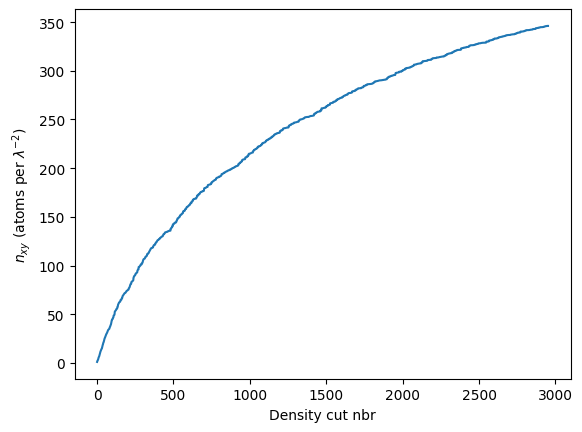

In [9]:
close("all")
fig = subplot()

plot(CS_densities_cuts_interpolated_norm)

xlabel("Density cut nbr")
ylabel(L"$n_{xy}$ (atoms per $\lambda^{-2}$)")

# pygui(true); show()
pygui(false);